# N Asset Efficient Frontier

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import kit as erk

In [ ]:
ind = erk.get_ind_returns()
er = erk.annual_return(ind["1996":"2000"], 12)
cov = ind["1996":"2000"].cov()

/Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/9. Introduction to Portfolio Construction/kit.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv("data/ind30_m_vw_rets.csv", header=0, index_col=0,parse_dates=True)/100


In [ ]:
er.shape


(30,)

```python

def plot_ef2(npoints, er, cov, style=".-"):
    """Plot N-asset efficient frontier"""
    target_rs = np.linspace(er.min(), er.max(), npoints)
    weights = [minimize_vol(r, er, cov) for r in target_rs]
    rets = [portfolio_return(w, er) for w in weights]
    vols = [portfolio_vol(w, cov) for w in weights]
    ef = pd.DataFrame({"Returns": rets, "Volatility": vols})
    return ef.plot.line(x="Volatility", y="Returns", style=style)
```


In [ ]:
from scipy.optimize import minimize 

<Axes: xlabel='Volatility'>

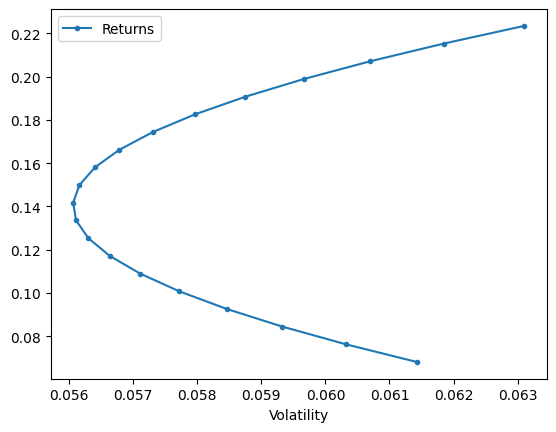

In [ ]:
l = ["Games", "Fin"]
erk.plot_ef2(20, er[l], cov.loc[l,l])

In [ ]:
import numpy as np

In [ ]:
w15 = erk.minimize_vol(0.15, er[l], cov.loc[l,l])
vol15 = erk.portfolio_vol(w15, cov.loc[l,l])
vol15

0.056163669406706564

In [ ]:
w15

array([0.47287631, 0.52712369])

In [ ]:
import pandas as pd
def optimal_weights(n_points, er, cov):
    """
    --> List of weight to run the optimizer on to minimize the vol
    """
    target_rs = np.linspace(er.min(), er.max(), n_points)
    weights = [erk.minimize_vol(target_rs, er, cov) for target_return in target_rs]
    return weights

def plot_ef(npoints, er, cov, style=".-"):
    """Plot N-asset efficient frontier"""
    weights = optimal_weights(npoints, er, cov)
    rets = [erk.portfolio_return(w, er) for w in weights]
    vols = [erk.portfolio_vol(w, cov) for w in weights]
    ef = pd.DataFrame({"Returns": rets, "Volatility": vols})
    return ef.plot.line(x="Volatility", y="Returns", style=style)


In [ ]:
l = ["Smoke", "Fin", "Games","Coal"]
plot_ef(25, er[l],cov.loc[l,l])